In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Hermes analysis started 🚀")

Hermes analysis started 🚀


In [2]:
from ucimlrepo import fetch_ucirepo

# Download the dataset from UCI
student_data = fetch_ucirepo(id=856)

# Separate input features and target
X = student_data.data.features
y = student_data.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (145, 31)
Target shape: (145, 1)


In [3]:
X.head()

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Attendance to classes,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID
0,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,1,2,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,3,2,2,3,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,1,2,2,1,1,2,2,1
3,1,1,1,3,1,2,1,2,1,2,...,1,1,2,3,2,2,1,3,2,1
4,2,2,1,3,2,2,1,3,1,4,...,1,2,1,2,2,2,1,2,2,1


In [4]:
y.head()

,OUTPUT Grade
0,1
1,1
2,1
3,1
4,1


In [5]:
print(X.columns.tolist())

['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type', 'Additional work', 'Regular artistic or sports activity', 'Do you have a partner', 'Total salary if available', 'Transportation to the university', 'Accomodation type in Cyprus', "Mother's education", "Father's education", 'Number of sisters/brothers (if available)', 'Parental status', "Mother's occupation", "Father's occupation", 'Weekly study hours', 'Reading frequency (non-scientific books/journals)', 'Reading frequency (scientific books/journals)', 'Attendance to the seminars/conferences related to the department', 'Impact of your projects/activities on your success', 'Attendance to classes', 'Preparation to midterm exams 1', 'Preparation to midterm exams 2', 'Taking notes in classes', 'Listening in classes', 'Discussion improves my interest and success in the course', 'Flip-classroom', 'Cumulative grade point average in the last semester (/4.00)', 'Expected Cumulative grade point average in the graduation (/4

In [6]:
student_data.variables

,name,role,type,demographic,description,units,missing_values
0,Student Age,Feature,Categorical,Age,"1: 18-21, 2: 22-25, 3: above 26",None,no
1,Sex,Feature,Binary,Sex,"1: female, 2: male",None,no
2,Graduated high-school type,Feature,Categorical,Education Level,"1: private, 2: state, 3: other",None,no
3,Scholarship type,Feature,Categorical,NaN,"1: None, 2: 25%, 3: 50%, 4: 75%, 5: Full",None,no
4,Additional work,Feature,Binary,NaN,"1: Yes, 2: No",None,no
5,Regular artistic or sports activity,Feature,Binary,NaN,"1: Yes, 2: No",None,no
6,Do you have a partner,Feature,Binary,Marital Status,"1: Yes, 2: No",None,no
7,Total salary if available,Feature,Categorical,Income,"1: USD 135-200, 2: USD 201-270, 3: USD 271-340...",None,no
8,Transportation to the university,Feature,Categorical,NaN,"1: Bus, 2: Private car/taxi, 3: bicycle, 4: Other",None,no
9,Accomodation type in Cyprus,Feature,Categorical,NaN,"1: rental, 2: dormitory, 3: with family, 4: Other",None,no


In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 31 columns):
 #   Column                                                             Non-Null Count  Dtype
---  ------                                                             --------------  -----
 0   Student Age                                                        145 non-null    int64
 1   Sex                                                                145 non-null    int64
 2   Graduated high-school type                                         145 non-null    int64
 3   Scholarship type                                                   145 non-null    int64
 4   Additional work                                                    145 non-null    int64
 5   Regular artistic or sports activity                                145 non-null    int64
 6   Do you have a partner                                              145 non-null    int64
 7   Total salary if available                              

In [8]:
X.isnull().sum()

Student Age                                                          0
Sex                                                                  0
Graduated high-school type                                           0
Scholarship type                                                     0
Additional work                                                      0
Regular artistic or sports activity                                  0
Do you have a partner                                                0
Total salary if available                                            0
Transportation to the university                                     0
Accomodation type in Cyprus                                          0
Mother's education                                                   0
Father's education                                                   0
Number of sisters/brothers (if available)                            0
Parental status                                                      0
Mother

In [9]:
X.duplicated().sum()

np.int64(0)

In [10]:
y.value_counts()

OUTPUT Grade
1               35
2               24
3               21
5               17
7               17
6               13
4               10
0                8
Name: count, dtype: int64

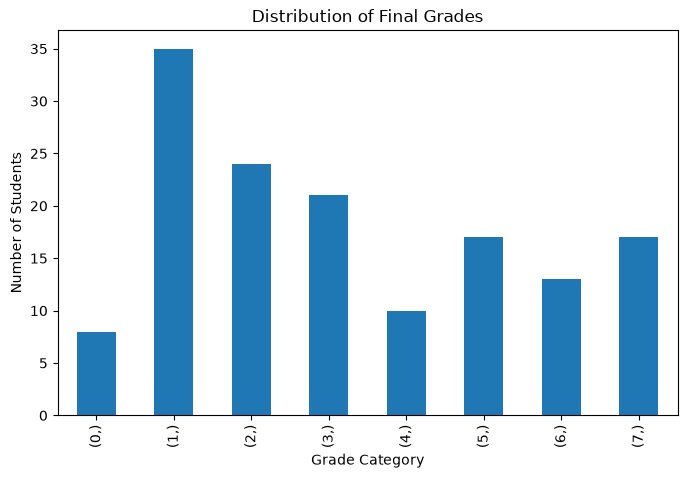

In [11]:
y.value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Final Grades")
plt.xlabel("Grade Category")
plt.ylabel("Number of Students")

plt.show()

In [12]:
for i, column in enumerate(X.columns):
    print(i, column)

0 Student Age
1 Sex
2 Graduated high-school type
3 Scholarship type
4 Additional work
5 Regular artistic or sports activity
6 Do you have a partner
7 Total salary if available
8 Transportation to the university
9 Accomodation type in Cyprus
10 Mother's education
11 Father's education
12 Number of sisters/brothers (if available)
13 Parental status
14 Mother's occupation
15 Father's occupation
16 Weekly study hours
17 Reading frequency (non-scientific books/journals)
18 Reading frequency (scientific books/journals)
19 Attendance to the seminars/conferences related to the department
20 Impact of your projects/activities on your success
21 Attendance to classes
22 Preparation to midterm exams 1
23 Preparation to midterm exams 2
24 Taking notes in classes
25 Listening in classes
26 Discussion improves my interest and success in the course
27 Flip-classroom
28 Cumulative grade point average in the last semester (/4.00)
29 Expected Cumulative grade point average in the graduation (/4.00)
30 C

In [13]:
df = X.copy()

df["GRADE"] = y.values.ravel()

df.head()

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,GRADE
0,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,1,2,1,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,3,2,2,3,1,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,2,2,1,1,2,2,1,1
3,1,1,1,3,1,2,1,2,1,2,...,1,2,3,2,2,1,3,2,1,1
4,2,2,1,3,2,2,1,3,1,4,...,2,1,2,2,2,1,2,2,1,1


In [14]:
correlations = df.corr(numeric_only=True)["GRADE"]

correlations.sort_values(ascending=False)

GRADE                                                                1.000000
Sex                                                                  0.335533
Cumulative grade point average in the last semester (/4.00)          0.315493
Expected Cumulative grade point average in the graduation (/4.00)    0.248588
Reading frequency (non-scientific books/journals)                    0.195617
Additional work                                                      0.167445
Discussion improves my interest and success in the course            0.146547
Course ID                                                            0.142166
Flip-classroom                                                       0.110617
Graduated high-school type                                           0.104821
Listening in classes                                                 0.085137
Number of sisters/brothers (if available)                            0.084470
Preparation to midterm exams 2                                  

In [15]:
top_correlations = (
    correlations
    .drop("GRADE")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_correlations

Sex                                                                  0.335533
Cumulative grade point average in the last semester (/4.00)          0.315493
Expected Cumulative grade point average in the graduation (/4.00)    0.248588
Impact of your projects/activities on your success                   0.203273
Reading frequency (non-scientific books/journals)                    0.195617
Attendance to the seminars/conferences related to the department     0.184763
Additional work                                                      0.167445
Total salary if available                                            0.166352
Transportation to the university                                     0.156289
Discussion improves my interest and success in the course            0.146547
Name: GRADE, dtype: float64

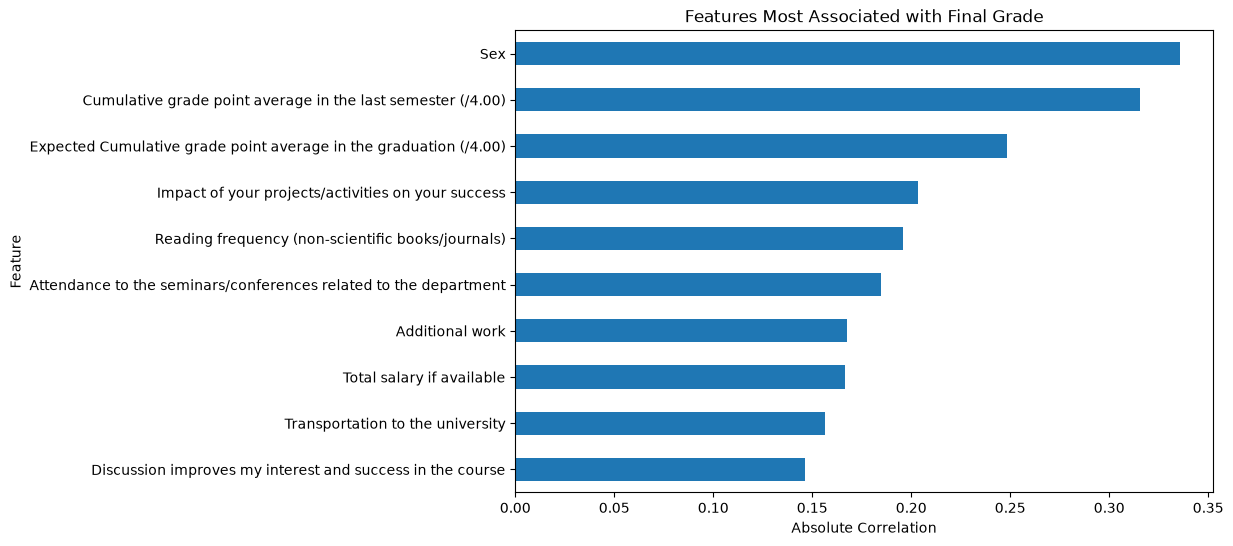

In [16]:
top_correlations.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Features Most Associated with Final Grade")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.ravel(),
    test_size=0.2,
    random_state=42,
    stratify=y.values.ravel()
)

print("Training students:", len(X_train))
print("Testing students:", len(X_test))

Training students: 116
Testing students: 29


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=5000
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [19]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

print("\nActual grades:")
print(y_test)

Predictions:
[5 5 3 5 4 1 1 2 6 2 3 1 2 6 2 6 3 2 5 1 1 0 5 2 3 1 6 3 2]

Actual grades:
[5 5 2 4 1 5 1 1 7 3 7 2 1 7 2 6 3 1 2 6 0 0 3 4 6 3 1 1 2]


In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 27.59%


In [21]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_pred)

print(f"Dummy baseline: {dummy_accuracy:.2%}")
print(f"Hermes Logistic Regression: {accuracy:.2%}")

Dummy baseline: 24.14%
Hermes Logistic Regression: 27.59%


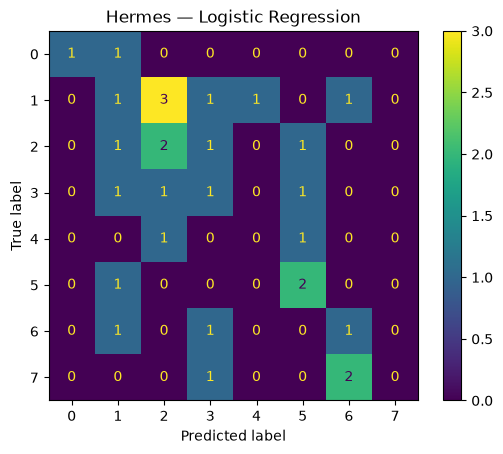

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Hermes — Logistic Regression")
plt.show()

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.17      0.14      0.15         7
           2       0.29      0.40      0.33         5
           3       0.20      0.25      0.22         4
           4       0.00      0.00      0.00         2
           5       0.40      0.67      0.50         3
           6       0.25      0.33      0.29         3
           7       0.00      0.00      0.00         3

    accuracy                           0.28        29
   macro avg       0.29      0.29      0.27        29
weighted avg       0.25      0.28      0.25        29



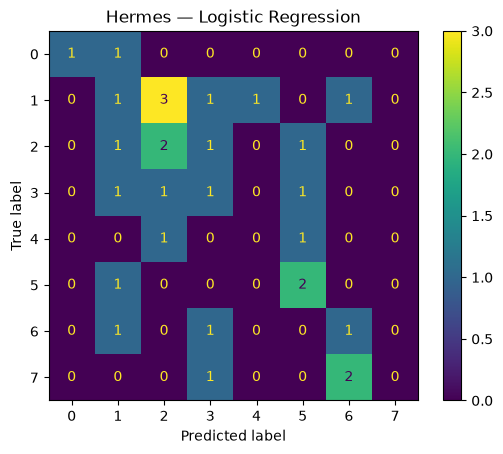

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Hermes — Logistic Regression")
plt.show()

In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.17      0.14      0.15         7
           2       0.29      0.40      0.33         5
           3       0.20      0.25      0.22         4
           4       0.00      0.00      0.00         2
           5       0.40      0.67      0.50         3
           6       0.25      0.33      0.29         3
           7       0.00      0.00      0.00         3

    accuracy                           0.28        29
   macro avg       0.29      0.29      0.27        29
weighted avg       0.25      0.28      0.25        29



In [26]:
import numpy as np

mae = np.mean(np.abs(y_test - y_pred))

print(f"Mean Absolute Grade Error: {mae:.2f}")

Mean Absolute Grade Error: 1.55


In [27]:
errors = np.abs(y_test - y_pred)

print("Exact grade:", np.mean(errors == 0))
print("Within ±1 grade:", np.mean(errors <= 1))
print("Within ±2 grades:", np.mean(errors <= 2))

Exact grade: 0.27586206896551724
Within ±1 grade: 0.6206896551724138
Within ±2 grades: 0.7586206896551724


In [28]:
mae = np.mean(np.abs(y_test - y_pred))

print(f"Mean Absolute Grade Error: {mae:.2f}")

Mean Absolute Grade Error: 1.55


# Hermes Benchmark Engine 🪽

In [29]:
from sklearn.metrics import accuracy_score
import numpy as np

In [30]:
print(df.columns.tolist())

['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type', 'Additional work', 'Regular artistic or sports activity', 'Do you have a partner', 'Total salary if available', 'Transportation to the university', 'Accomodation type in Cyprus', "Mother's education", "Father's education", 'Number of sisters/brothers (if available)', 'Parental status', "Mother's occupation", "Father's occupation", 'Weekly study hours', 'Reading frequency (non-scientific books/journals)', 'Reading frequency (scientific books/journals)', 'Attendance to the seminars/conferences related to the department', 'Impact of your projects/activities on your success', 'Attendance to classes', 'Preparation to midterm exams 1', 'Preparation to midterm exams 2', 'Taking notes in classes', 'Listening in classes', 'Discussion improves my interest and success in the course', 'Flip-classroom', 'Cumulative grade point average in the last semester (/4.00)', 'Expected Cumulative grade point average in the graduation (/4

In [31]:
# Features (Input)
X = df.drop(columns=["GRADE"])

# Target (Output)
y = df[["GRADE"]]

In [32]:
print(X.shape)
print(y.shape)

print(X.columns)
print(y.columns)

(145, 31)
(145, 1)
Index(['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type',
       'Additional work', 'Regular artistic or sports activity',
       'Do you have a partner', 'Total salary if available',
       'Transportation to the university', 'Accomodation type in Cyprus',
       'Mother's education', 'Father's education',
       'Number of sisters/brothers (if available)', 'Parental status',
       'Mother's occupation', 'Father's occupation', 'Weekly study hours',
       'Reading frequency (non-scientific books/journals)',
       'Reading frequency (scientific books/journals)',
       'Attendance to the seminars/conferences related to the department',
       'Impact of your projects/activities on your success',
       'Attendance to classes', 'Preparation to midterm exams 1',
       'Preparation to midterm exams 2', 'Taking notes in classes',
       'Listening in classes',
       'Discussion improves my interest and success in the course',
       'Flip-classro

In [33]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, predictions)

    mae = np.mean(np.abs(y_test - predictions))

    within_one = np.mean(np.abs(y_test - predictions) <= 1)

    return {
        "Model": model.__class__.__name__,
        "Accuracy": accuracy,
        "MAE": mae,
        "Within ±1": within_one
    }

In [34]:
from sklearn.linear_model import LogisticRegression

logistic = LogisticRegression(
    max_iter=5000
)

results = evaluate_model(
    logistic,
    X_train,
    X_test,
    y_train,
    y_test
)

results

{'Model': 'LogisticRegression',
 'Accuracy': 0.27586206896551724,
 'MAE': np.float64(1.5517241379310345),
 'Within ±1': np.float64(0.6206896551724138)}

In [35]:
import pandas as pd

benchmark = pd.DataFrame([results])

benchmark

,Model,Accuracy,MAE,Within ±1
0,LogisticRegression,0.275862,1.551724,0.62069


In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

dt_results

{'Model': 'DecisionTreeClassifier',
 'Accuracy': 0.3103448275862069,
 'MAE': np.float64(1.4482758620689655),
 'Within ±1': np.float64(0.6206896551724138)}

In [38]:
benchmark.loc[len(benchmark)] = dt_results

benchmark

,Model,Accuracy,MAE,Within ±1
0,LogisticRegression,0.275862,1.551724,0.62069
1,DecisionTreeClassifier,0.310345,1.448276,0.62069


In [39]:
benchmark["Accuracy"] = benchmark["Accuracy"].map(lambda x: f"{x:.2%}")
benchmark["Within ±1"] = benchmark["Within ±1"].map(lambda x: f"{x:.2%}")
benchmark["MAE"] = benchmark["MAE"].round(2)

benchmark

,Model,Accuracy,MAE,Within ±1
0,LogisticRegression,27.59%,1.55,62.07%
1,DecisionTreeClassifier,31.03%,1.45,62.07%


In [40]:
benchmark = benchmark.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

benchmark

,Model,Accuracy,MAE,Within ±1
0,DecisionTreeClassifier,31.03%,1.45,62.07%
1,LogisticRegression,27.59%,1.55,62.07%


In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results

{'Model': 'RandomForestClassifier',
 'Accuracy': 0.3103448275862069,
 'MAE': np.float64(1.2758620689655173),
 'Within ±1': np.float64(0.6551724137931034)}

In [43]:
benchmark.loc[len(benchmark)] = rf_results
benchmark

,Model,Accuracy,MAE,Within ±1
0,DecisionTreeClassifier,31.03%,1.450000,62.07%
1,LogisticRegression,27.59%,1.550000,62.07%
2,RandomForestClassifier,0.310345,1.275862,0.655172


In [44]:
benchmark["Model"] = benchmark["Model"].replace({
    "LogisticRegression": "Logistic Regression",
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest"
})

benchmark

,Model,Accuracy,MAE,Within ±1
0,Decision Tree,31.03%,1.450000,62.07%
1,Logistic Regression,27.59%,1.550000,62.07%
2,Random Forest,0.310345,1.275862,0.655172


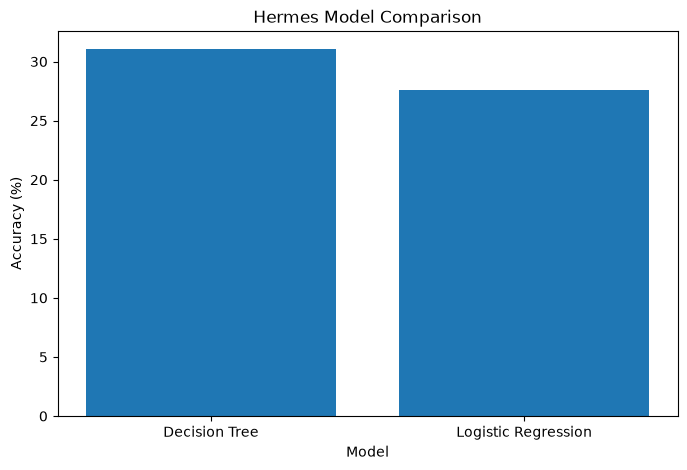

In [45]:
import matplotlib.pyplot as plt

# Convert percentages back to numbers if needed
plot_df = benchmark.copy()
plot_df["Accuracy"] = (
    plot_df["Accuracy"]
    .str.rstrip("%")
    .astype(float)
)

plt.figure(figsize=(8,5))

plt.bar(plot_df["Model"], plot_df["Accuracy"])
plt.title("Hermes Model Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.show()

In [46]:
from sklearn.neighbors import KNeighborsClassifier

In [47]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn_results = evaluate_model(
    knn,
    X_train,
    X_test,
    y_train,
    y_test
)

knn_results

{'Model': 'KNeighborsClassifier',
 'Accuracy': 0.41379310344827586,
 'MAE': np.float64(1.3103448275862069),
 'Within ±1': np.float64(0.6551724137931034)}

In [48]:
benchmark.loc[len(benchmark)] = knn_results
benchmark

,Model,Accuracy,MAE,Within ±1
0,Decision Tree,31.03%,1.450000,62.07%
1,Logistic Regression,27.59%,1.550000,62.07%
2,Random Forest,0.310345,1.275862,0.655172
3,KNeighborsClassifier,0.413793,1.310345,0.655172


In [49]:
benchmark.dtypes

Model            str
Accuracy      object
MAE          float64
Within ±1     object
dtype: object

In [50]:
benchmark

,Model,Accuracy,MAE,Within ±1
0,Decision Tree,31.03%,1.450000,62.07%
1,Logistic Regression,27.59%,1.550000,62.07%
2,Random Forest,0.310345,1.275862,0.655172
3,KNeighborsClassifier,0.413793,1.310345,0.655172


In [51]:
benchmark.dtypes

Model            str
Accuracy      object
MAE          float64
Within ±1     object
dtype: object

In [52]:
benchmark = pd.DataFrame([
    evaluate_model(
        LogisticRegression(max_iter=5000),
        X_train, X_test, y_train, y_test
    ),

    evaluate_model(
        DecisionTreeClassifier(random_state=42),
        X_train, X_test, y_train, y_test
    ),

    evaluate_model(
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        X_train, X_test, y_train, y_test
    ),

    evaluate_model(
        KNeighborsClassifier(n_neighbors=5),
        X_train, X_test, y_train, y_test
    )
])

In [53]:
benchmark = benchmark.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

benchmark

,Model,Accuracy,MAE,Within ±1
0,KNeighborsClassifier,0.413793,1.310345,0.655172
1,DecisionTreeClassifier,0.310345,1.448276,0.620690
2,RandomForestClassifier,0.310345,1.275862,0.655172
3,LogisticRegression,0.275862,1.551724,0.620690


In [54]:
benchmark

,Model,Accuracy,MAE,Within ±1
0,KNeighborsClassifier,0.413793,1.310345,0.655172
1,DecisionTreeClassifier,0.310345,1.448276,0.620690
2,RandomForestClassifier,0.310345,1.275862,0.655172
3,LogisticRegression,0.275862,1.551724,0.620690


In [55]:
benchmark = benchmark.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

In [56]:
display_df = benchmark.copy()

display_df["Model"] = display_df["Model"].replace({
    "LogisticRegression": "Logistic Regression",
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest",
    "KNeighborsClassifier": "KNN"
})

display_df["Accuracy"] = display_df["Accuracy"].map(lambda x: f"{x:.2%}")
display_df["Within ±1"] = display_df["Within ±1"].map(lambda x: f"{x:.2%}")
display_df["MAE"] = display_df["MAE"].round(2)

display_df

,Model,Accuracy,MAE,Within ±1
0,KNN,41.38%,1.31,65.52%
1,Decision Tree,31.03%,1.45,62.07%
2,Random Forest,31.03%,1.28,65.52%
3,Logistic Regression,27.59%,1.55,62.07%


In [57]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
print(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

c:\Users\ASUS\OneDrive\Desktop\Hermes


In [58]:
display_df = benchmark.copy()

display_df["Model"] = display_df["Model"].replace({
    "LogisticRegression": "Logistic Regression",
    "DecisionTreeClassifier": "Decision Tree",
    "RandomForestClassifier": "Random Forest",
    "KNeighborsClassifier": "KNN"
})

display_df["Accuracy"] = display_df["Accuracy"].apply(lambda x: f"{x:.2%}")
display_df["Within ±1"] = display_df["Within ±1"].apply(lambda x: f"{x:.2%}")
display_df["MAE"] = display_df["MAE"].round(2)

display_df

,Model,Accuracy,MAE,Within ±1
0,KNN,41.38%,1.31,65.52%
1,Decision Tree,31.03%,1.45,62.07%
2,Random Forest,31.03%,1.28,65.52%
3,Logistic Regression,27.59%,1.55,62.07%


In [59]:
from sklearn.model_selection import cross_val_score

# Cross Validation

In [60]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [61]:
cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": name,
        "Fold 1": scores[0],
        "Fold 2": scores[1],
        "Fold 3": scores[2],
        "Fold 4": scores[3],
        "Fold 5": scores[4],
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    })

c:\Users\ASUS\OneDrive\Desktop\Hermes\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ASUS\OneDrive\Desktop\Hermes\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ASUS\OneDrive\Desktop\Hermes\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ASUS\OneDrive\Desktop\Hermes\.venv\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was pass

In [62]:
scores.mean()

np.float64(0.2689655172413793)

In [63]:
scores.std()

np.float64(0.10772758173664353)

In [64]:
cv_df = pd.DataFrame(cv_results)

display_cv = cv_df.copy()

fold_columns = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5",
    "Mean Accuracy"
]

for column in fold_columns:
    display_cv[column] = display_cv[column].apply(lambda x: f"{x:.2%}")

display_cv["Std Dev"] = display_cv["Std Dev"].round(4)

display_cv = display_cv.sort_values(
    by="Mean Accuracy",
    ascending=False
)

display_cv

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Std Dev
2,Random Forest,37.93%,24.14%,44.83%,27.59%,17.24%,30.34%,0.0985
3,KNN,34.48%,24.14%,34.48%,34.48%,6.90%,26.90%,0.1077
0,Logistic Regression,34.48%,17.24%,31.03%,24.14%,13.79%,24.14%,0.0786
1,Decision Tree,17.24%,20.69%,31.03%,17.24%,27.59%,22.76%,0.0560


In [65]:
import matplotlib.pyplot as plt

# Feature Importance Analysis

In [66]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [67]:
rf_model.feature_importances_

array([0.0286957 , 0.03463796, 0.02548786, 0.03193272, 0.02190621,
       0.02429261, 0.02186483, 0.03190832, 0.02098568, 0.02973601,
       0.05332519, 0.04036417, 0.05550213, 0.0140355 , 0.02360687,
       0.04356514, 0.0413927 , 0.02237134, 0.02513327, 0.0178144 ,
       0.01724967, 0.02077469, 0.02696595, 0.00891258, 0.02519928,
       0.04509199, 0.01941077, 0.03788598, 0.0651318 , 0.04348179,
       0.08133688])

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
30,Course ID,0.081337
28,Cumulative grade point average in the last sem...,0.065132
12,Number of sisters/brothers (if available),0.055502
10,Mother's education,0.053325
25,Listening in classes,0.045092
15,Father's occupation,0.043565
29,Expected Cumulative grade point average in the...,0.043482
16,Weekly study hours,0.041393
11,Father's education,0.040364
27,Flip-classroom,0.037886


In [69]:
experiment_df = df.drop(columns=["Course ID"])

In [70]:
X.columns

Index(['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type',
       'Additional work', 'Regular artistic or sports activity',
       'Do you have a partner', 'Total salary if available',
       'Transportation to the university', 'Accomodation type in Cyprus',
       'Mother's education', 'Father's education',
       'Number of sisters/brothers (if available)', 'Parental status',
       'Mother's occupation', 'Father's occupation', 'Weekly study hours',
       'Reading frequency (non-scientific books/journals)',
       'Reading frequency (scientific books/journals)',
       'Attendance to the seminars/conferences related to the department',
       'Impact of your projects/activities on your success',
       'Attendance to classes', 'Preparation to midterm exams 1',
       'Preparation to midterm exams 2', 'Taking notes in classes',
       'Listening in classes',
       'Discussion improves my interest and success in the course',
       'Flip-classroom',
       'Cumula

In [71]:
type(y)

pandas.DataFrame

In [72]:
type(X)

pandas.DataFrame

In [73]:
y.columns

Index(['GRADE'], dtype='str')

In [74]:
experiment_df = df.drop(columns=["Course ID"])

In [75]:
X.columns

Index(['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type',
       'Additional work', 'Regular artistic or sports activity',
       'Do you have a partner', 'Total salary if available',
       'Transportation to the university', 'Accomodation type in Cyprus',
       'Mother's education', 'Father's education',
       'Number of sisters/brothers (if available)', 'Parental status',
       'Mother's occupation', 'Father's occupation', 'Weekly study hours',
       'Reading frequency (non-scientific books/journals)',
       'Reading frequency (scientific books/journals)',
       'Attendance to the seminars/conferences related to the department',
       'Impact of your projects/activities on your success',
       'Attendance to classes', 'Preparation to midterm exams 1',
       'Preparation to midterm exams 2', 'Taking notes in classes',
       'Listening in classes',
       'Discussion improves my interest and success in the course',
       'Flip-classroom',
       'Cumula

In [76]:
X_exp = X.drop(columns=["Course ID"])

In [77]:
y_exp = y.squeeze()

In [78]:
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp,
    y_exp,
    test_size=0.2,
    random_state=42
)

In [79]:
rf_exp = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

scores_exp = cross_val_score(
    rf_exp,
    X_exp,
    y_exp,
    cv=5,
    scoring="accuracy"
)

print("Mean Accuracy:", scores_exp.mean())
print("Std Dev:", scores_exp.std())

Mean Accuracy: 0.27586206896551724
Std Dev: 0.05770069148510867


<Figure size 1000x800 with 0 Axes>

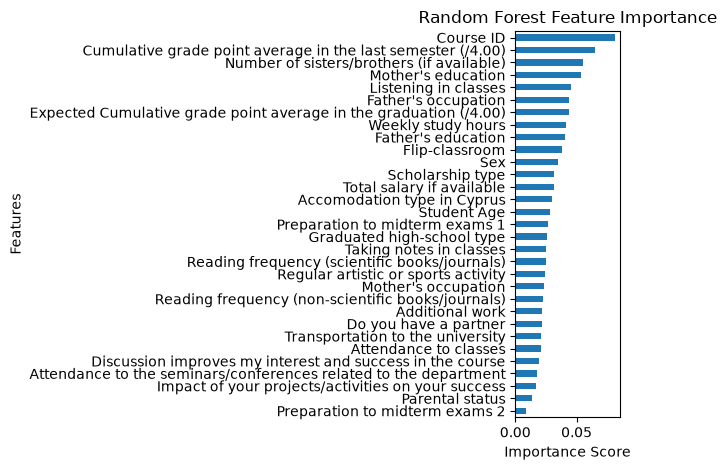

In [80]:
plt.figure(figsize=(10, 8))

feature_importance.sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

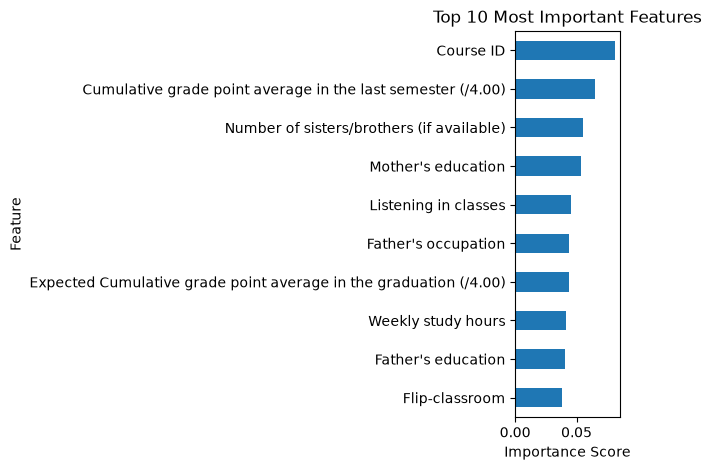

In [81]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

top_features.sort_values("Importance").plot(
    kind="barh",
    x="Feature",
    y="Importance",
    legend=False
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [82]:
from sklearn.model_selection import GridSearchCV

In [83]:
from hermes.models import random_forest

In [84]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [85]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [86]:
grid_search.fit(X, y.squeeze())

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbo

In [87]:
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Accuracy: 0.33103448275862074


In [88]:
import joblib

In [89]:
from hermes.models import random_forest

best_rf = random_forest()

best_rf.fit(X, y.squeeze())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

In [90]:
joblib.dump(best_rf, "../model/hermes_rf.pkl")

['../model/hermes_rf.pkl']

# Prediction Pipeline

In [91]:
loaded_model = joblib.load("../model/hermes_v1.0.pkl")

In [92]:
sample_student = X.iloc[[0]]

In [93]:
prediction = loaded_model.predict(sample_student)

prediction

array([1])

In [94]:
print("Predicted Grade:", prediction[0])
print("Actual Grade:", y.iloc[0, 0])

Predicted Grade: 1
Actual Grade: 1


In [95]:
from hermes.prediction import HermesPredictor

In [96]:
hermes = HermesPredictor("../model/hermes_v1.0.pkl")

In [97]:
prediction = hermes.predict(sample_student)

print(prediction)

[1]


In [98]:
import importlib
import hermes.models

importlib.reload(hermes.models)

<module 'hermes.models' from 'c:\\Users\\ASUS\\OneDrive\\Desktop\\Hermes\\hermes\\models.py'>

In [99]:
from hermes.models import random_forest

model = random_forest()

print(model)

RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)


In [100]:
import importlib
import hermes.visualization

importlib.reload(hermes.visualization)

<module 'hermes.visualization' from 'c:\\Users\\ASUS\\OneDrive\\Desktop\\Hermes\\hermes\\visualization.py'>

In [101]:
from hermes.visualization import (
    plot_model_comparison,
    plot_feature_importance,
    plot_cross_validation
)

In [102]:
from hermes.models import random_forest
from hermes.evaluation import evaluate_model
from hermes.prediction import HermesPredictor
from hermes.visualization import (
    plot_model_comparison,
    plot_feature_importance,
    plot_cross_validation
)

In [103]:
for column in [
    "Sex",
    "Graduated high-school type",
    "Scholarship type",
    "Additional work",
    "Regular artistic or sports activity",
    "Do you have a partner",
    "Transportation to the university",
    "Accomodation type in Cyprus",
    "Parental status"
]:
    print(f"\n{column}")
    print(sorted(df[column].unique()))


Sex
[np.int64(1), np.int64(2)]

Graduated high-school type
[np.int64(1), np.int64(2), np.int64(3)]

Scholarship type
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Additional work
[np.int64(1), np.int64(2)]

Regular artistic or sports activity
[np.int64(1), np.int64(2)]

Do you have a partner
[np.int64(1), np.int64(2)]

Transportation to the university
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Accomodation type in Cyprus
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Parental status
[np.int64(1), np.int64(2), np.int64(3)]


In [104]:
import importlib
import hermes.visualization

importlib.reload(hermes.visualization)

<module 'hermes.visualization' from 'c:\\Users\\ASUS\\OneDrive\\Desktop\\Hermes\\hermes\\visualization.py'>

In [105]:
from hermes.visualization import (
    plot_model_comparison,
    plot_feature_importance,
    plot_cross_validation
)

In [106]:
for column in X.columns:
    print(f"\n{column}")
    print(sorted(df[column].unique()))


Student Age
[np.int64(1), np.int64(2), np.int64(3)]

Sex
[np.int64(1), np.int64(2)]

Graduated high-school type
[np.int64(1), np.int64(2), np.int64(3)]

Scholarship type
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Additional work
[np.int64(1), np.int64(2)]

Regular artistic or sports activity
[np.int64(1), np.int64(2)]

Do you have a partner
[np.int64(1), np.int64(2)]

Total salary if available
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Transportation to the university
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Accomodation type in Cyprus
[np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Mother's education
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Father's education
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Number of sisters/brothers (if available)
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Parental status
[np.int64(1), np.in